# Task 6: House Price Prediction

# Objective

To predict house prices using housing features such as location, income, population, rooms, and proximity to the ocean.

# Model Used
Linear Regression

# Preprocessing
### 1. Numerical Data
* Fill missing values
* Scale features
### 2. Categorical Data
* Convert text to numbers

# Evaluation Metrics
Mean Absolute Error (MAE)
Root Mean Squared Error (RMSE)

## Import the Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## Load the Dataset

In [69]:
house=pd.read_csv('housing.csv')

## Exploratory Data Analysis (EDA)

In [70]:
print('\nShape:\n')
print(house.shape)
print('-------------------------------')
print('\nColumns:\n')
print(house.columns)
print('-------------------------------')
print('\nRows:\n')
print(house.head())
print('-------------------------------')
print('\nMissing Values:\n')
print(house.isnull().sum())


Shape:

(20640, 10)
-------------------------------

Columns:

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
-------------------------------

Rows:

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY 

## Dataset Information

In [71]:
print(house.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


##Summary Statistics

In [72]:
print(house.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

## Features and Target

In [73]:
x=house.drop("median_house_value", axis=1)
y=house["median_house_value"]

## Separate Numerical and Categorical Columns

In [74]:
num_cols=x.select_dtypes(include=["float64", "int64"]).columns
cat_cols=x.select_dtypes(include=["object"]).columns

## Preprocessing

In [75]:
numeric_transformer=Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scalar", StandardScaler())
])
categorical_transformer=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer([
    ("num",numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

## Split the Dataset

In [76]:
x_train, x_test, y_train, y_test=train_test_split(
    x,y,test_size=0.2, random_state=42
)

## Train Linear Regression Model

In [77]:
model=Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('regressor', LinearRegression())])

## Make Predictions

In [78]:
y_pred=model.predict(x_test)

## Evaluate Model

### **1. MAE**

In [79]:
mae= mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error', mae)

Mean Absolute Error 50670.48923565361


### **2. RMSE**

In [80]:
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error', rmse)

Root Mean Squared Error 70059.19333925014


## Actual vs Predicted Visualization

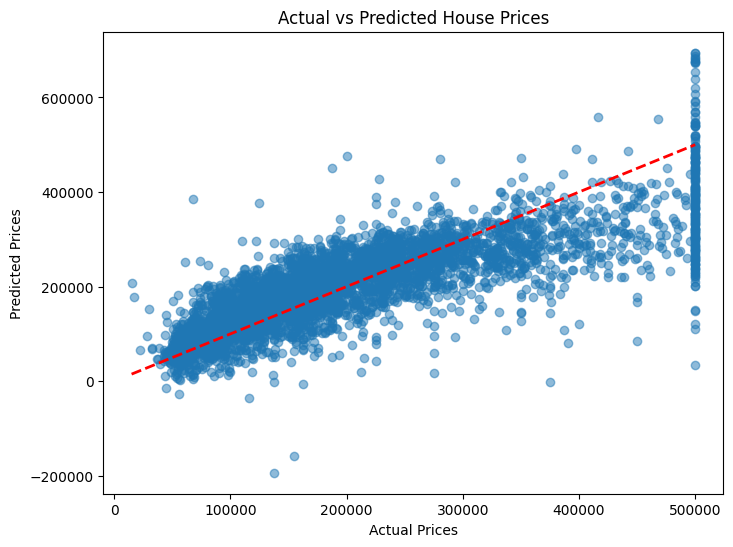

In [81]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

## Sample Predictions

In [82]:
results=pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
print(results.head(10))

   Actual Price  Predicted Price
0       47700.0     54261.027690
1       45800.0    124430.917728
2      500001.0    255694.958282
3      218600.0    268208.010360
4      278000.0    262975.013606
5      158700.0    139811.882746
6      198200.0    290871.002705
7      157500.0    228470.455166
8      340000.0    256712.364401
9      446600.0    408129.437226


# Visualization

A scatter plot was generated to compare actual house prices with predicted prices.

# Conclusion

The Linear Regression model successfully predicted house prices based on housing characteristics. Model performance was evaluated using MAE and RMSE, showing the effectiveness of regression techniques for real estate price prediction.

## Results and Insights

- Missing values in total_bedrooms were handled using median imputation.
- Numerical features were standardized.
- The categorical feature ocean_proximity was encoded using One-Hot Encoding.
- A Linear Regression model was trained to predict house prices.
- MAE = 50,670.49
- RMSE = 70,059.19
- The Actual vs Predicted plot shows a positive relationship between predicted and actual values.